In [2]:
import sys,os
sys.path.append('../../')
os.environ["JAX_PLATFORMS"] = "cpu"
import matplotlib.pyplot as plt
import numpy as np
from utils import makefolder,depths,reduce_list_half_preserve_extremes,my_languages

from geometry import * 

eps = 1E-7
rcpsize = 14
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['ggplot']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# print(plt.rcParams.keys())
#np.set_printoptions(precision=None)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']
plot_id = 0

/home/acevedo/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
modelA = 'deepseek'
# modelA = 'llama8b'
# modelA = 'qwen7b'
modelB = modelA

layers_A = list(range(1,depths[modelA] + 1))
layers_B = list(range(1,depths[modelB] + 1))
layers = np.array(reduce_list_half_preserve_extremes(layers_A),dtype=int)
relative_depth = layers.astype(float) / depths[modelB]

languages = [
            'english',
            # 'italian',
            # 'spanish',
            # 'german',
            # 'chinese',
            # 'arabic',
            # 'turkish',
            ]

batch_shuffle = 0
centers_var = 'sem'
min_token_length = 3
n_files = 21
n_tokens = min_token_length
avg_flags = [0,1]
match_var = 'matching'
data_var = 'sem'
Nbits = 0
language = 'english'

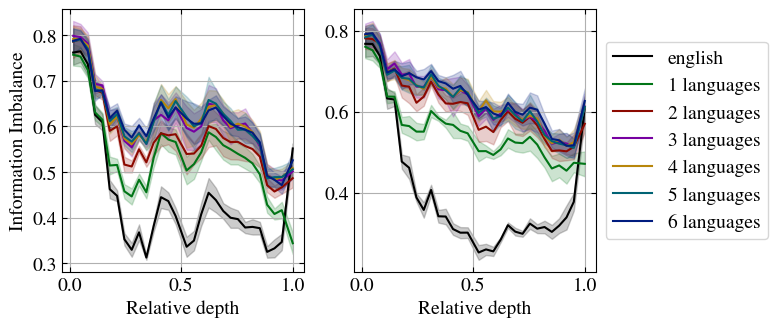

In [28]:
fig,ax = plt.subplots(1,2,figsize=(8,3.5))
ratio_jackknife = 0.5
plot_id = 0

def set_params(center_A_flag,
               center_B_flag,
               number_of_languages,
               language_list_permutation,
               removal_method,
               zero_activations,
               ):

  return  {'center_A_flag' : center_A_flag,
            'center_B_flag' : center_B_flag,
            'number_of_languages' : number_of_languages,
            'language_list_permutation' : language_list_permutation,
            'removal_method' : removal_method,
            'zero_activations' : zero_activations,
            }

params_list = [ ]

params_list.append(set_params(0,0,None,None,None,0))

for number_of_languages in [1,2,3,4,5,6]:
  params_list.append(set_params(1,1,number_of_languages,0,'projection',0))

inf_imb = np.zeros(shape=(len(params_list),2,len(layers)))
for avg_id,avg_tokens in enumerate(avg_flags):
  plot_id = 0
  if avg_tokens:
    _n_tokens = -1
    _min_token_length = -1
  else:
    _n_tokens = n_tokens
    _min_token_length = min_token_length
  for params_id,params in enumerate(params_list):
    title = ' '

    output_folder0 = makefolder(base=f'./results/',
                                global_centering=0,
                                spaces='AB',
                                similarity_fn='normalized_L2_distance',
                                precision=32,
                                language=language,
                                data_var=data_var,
                                modelA=modelA,
                                modelB=modelB,
                                match_var=match_var,
                                n_files=n_files,
                                min_token_length=_min_token_length,
                                )
    II_folder = makefolder(base=output_folder0,
                                      centers=centers_var,
                                      Nbits=Nbits,
                                      n_tokens=_n_tokens,
                                      avg_tokens=avg_tokens,
                                      batch_shuffle=batch_shuffle,
                                      zero_activations=params['zero_activations'],
                                      center_A_flag=params['center_A_flag'],
                                      center_B_flag=params['center_B_flag'],
                                      number_of_languages=params['number_of_languages'],
                                      language_list_permutation=params['language_list_permutation'],
                                      removal_method=params['removal_method'],
                                      )
    inf_imb[params_id] = np.load(II_folder + f"II_{ratio_jackknife:.2f}.npy").diagonal(axis1=-2,axis2=-1)
    std = np.load(II_folder + f"II_jack_std_{ratio_jackknife:.2f}.npy").diagonal(axis1=-2,axis2=-1)
    color = 'black' if plot_id == 0 else colors[plot_id%len(colors)] 
    
    if avg_tokens:
      title = f'Average'
    else:
      title = f'Concatenation'

    label = ''
    if params['center_A_flag'] == 0:
      label += f'{language}'
    else:
      label += f'{params["number_of_languages"]} languages'

    for II_index in range(1):
      ax[avg_id].plot(relative_depth,
              inf_imb[params_id][II_index],
              label=label,
              linestyle=_linestyles[II_index],
              color=color,
              ) 
      ax[avg_id].fill_between(relative_depth,
                      inf_imb[params_id][II_index] - std[II_index],
                      inf_imb[params_id][II_index] + std[II_index],
                      alpha=0.2,
                      color=color,
                      )
    plot_id += 1

  ax[avg_id].set_xlabel('Relative depth')
  if avg_id == 0:
    ax[avg_id].set_ylabel('Information Imbalance')
  # ax[avg_id].set_title(title + f' {modelA}')

  ax[avg_id].grid()
  ax[avg_id].tick_params(
      top=True, bottom=True, left=True, right=True,  # enable ticks
      labeltop=False, labelbottom=True, labelleft=True, labelright=False, # enable labels if needed
      direction='in'  # ticks point inward
      )
  # ax[avg_id].set_ylim(0.05,.85)
box = ax[1].get_position()
ax[1].set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
os.makedirs('results/figs', exist_ok=True)
fig.savefig(f'results/figs/number_of_languages_dependence_{modelA}.pdf', bbox_inches='tight')
plt.show()

In [30]:
inf_imb.shape

(7, 2, 30)

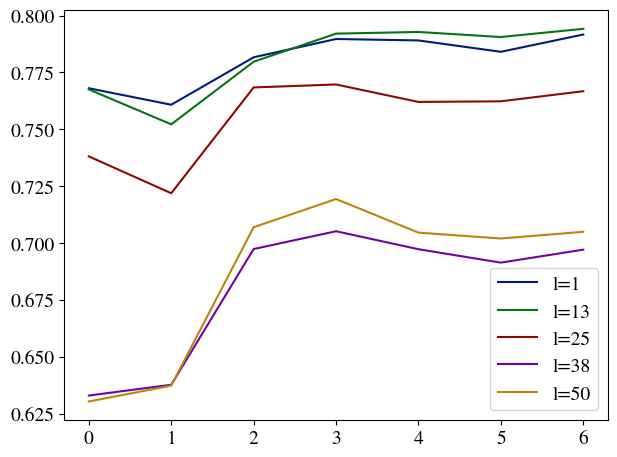

In [48]:
for l_id,l in enumerate(layers[::6]):
  plt.plot(inf_imb[:,0,l_id],label=f'{l=:d}')

plt.legend()


In [26]:
layers

array([ 1.,  3.,  5.,  7.,  9., 11., 13., 15., 17., 19., 21., 23., 25.,
       27., 29., 32., 34., 36., 38., 40., 42., 44., 46., 48., 50., 52.,
       54., 56., 58., 61.])

In [5]:
# fig,ax = plt.subplots(1,2,figsize=(9,3.5))

# def set_params(center_A_flag,
#                center_B_flag,
#                number_of_languages,
#                language_list_permutation,
#                removal_method,
#                zero_activations,
#                ):

#   return  {'center_A_flag' : center_A_flag,
#             'center_B_flag' : center_B_flag,
#             'number_of_languages' : number_of_languages,
#             'language_list_permutation' : language_list_permutation,
#             'removal_method' : removal_method,
#             'zero_activations' : zero_activations,
#             }



# language_list_permutations = [0,1,2,3,4,5] 


# for avg_id,avg_tokens in enumerate(avg_flags):
#   plot_id = 0
#   if avg_tokens:
#     title = f'Average | '
#     _n_tokens = -1
#     _min_token_length = -1
#   else:
#     title = f'Concatenation | '
#     _n_tokens = n_tokens
#     _min_token_length = min_token_length
  
#     # params_list.append(set_params(0,0,None,None,None,0)) # baseline
#     for number_of_languages in [None,3,6]:
#       inf_imb = np.zeros(shape=(len(language_list_permutations),2,len(layers)))
#       for permutation_id, language_list_permutation in enumerate(language_list_permutations):
        
#         if number_of_languages is None:
#           params = set_params(0,0,number_of_languages,None,None,0)
#         else:
#           # params = set_params(1,1,number_of_languages,language_list_permutation,'subtraction',0)
#           params = set_params(1,0,number_of_languages,language_list_permutation,'subtraction',0)
#         output_folder0 = makefolder(base=f'./results/',
#                                     global_centering=0,
#                                     spaces='AB',
#                                     similarity_fn='normalized_L2_distance',
#                                     precision=32,
#                                     language=language,
#                                     data_var=data_var,
#                                     modelA=modelA,
#                                     modelB=modelB,
#                                     match_var=match_var,
#                                     n_files=n_files,
#                                     min_token_length=_min_token_length,
#                                     )
#         II_folder = makefolder(base=output_folder0,
#                                           centers=centers_var,
#                                           Nbits=Nbits,
#                                           n_tokens=_n_tokens,
#                                           avg_tokens=avg_tokens,
#                                           batch_shuffle=batch_shuffle,
#                                           zero_activations=params['zero_activations'],
#                                           center_A_flag=params['center_A_flag'],
#                                           center_B_flag=params['center_B_flag'],
#                                           number_of_languages=params['number_of_languages'],
#                                           language_list_permutation=params['language_list_permutation'],
#                                           removal_method=params['removal_method'],
#                                           )

#         inf_imb[permutation_id,:,:] = np.diagonal(np.load(II_folder + "II.npy"),axis1=1,axis2=2)
#         color = colors[plot_id] 

#         label = ''
#         if params['center_A_flag'] == 0:
#           label += f'{language}'
#         else:
#           label += f'{params["number_of_languages"]} languages'

#       for II_index in range(1):
#         if number_of_languages == None: baseline = inf_imb[:,II_index,:].mean(axis=0)
#         ax[avg_id].plot(layers,
#                 inf_imb[:,II_index,:].mean(axis=0),
#                 label=label,
#                 linestyle=_linestyles[II_index],
#                 color=color,
#                 ) 
#         ax[avg_id].fill_between(layers,
#                         inf_imb[:,II_index,:].mean(axis=0) - inf_imb[:,II_index,:].std(axis=0),
#                         inf_imb[:,II_index,:].mean(axis=0) + inf_imb[:,II_index,:].std(axis=0),
#                         alpha=0.5,
#                         color=color,
#                         )
#       plot_id += 1

#       # if number_of_languages == 6:
#       #   ax[avg_id].plot(layers,
#       #                   inf_imb[:,II_index,:].mean(axis=0)-baseline,
#       #                   color='black',
#       #                   label='max_difference',
#       #                   )

#   ax[avg_id].set_xlabel('Relative depth')
#   if avg_id == 0:
#     ax[avg_id].set_ylabel('Information Imbalance')
#   ax[avg_id].set_title(title + f' {modelA}')

#   ax[avg_id].grid()
#   ax[avg_id].tick_params(
#       top=True, bottom=True, left=True, right=True,  # enable ticks
#       labeltop=False, labelbottom=True, labelleft=True, labelright=False, # enable labels if needed
#       direction='in'  # ticks point inward
#       )
#   # ax[avg_id].set_ylim(0.05,.85)
# box = ax[0].get_position()
# ax[0].set_position([box.x0, box.y0, box.width * 0.8, box.height])
# ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
# os.makedirs('results/figs', exist_ok=True)
# # fig.savefig(f'results/figs/semantic_similarity_{modelA}.pdf', bbox_inches='tight')
# plt.show()